In [140]:
import SigVarGen as svg
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

In [190]:
def generate_single_signal(domain):
    """
    Generate a single signal for a given domain, including base signal and interrupts.
    """

    drop=False
    
    signal_range, interrupt_range = svg.generate_device_parameters(svg.EMBEDDED_DEVICE_RANGES, drop=drop, frequency_follows_amplitude=False, split_ratios=[0.5, 0.5])

    amplitude_range = signal_range[domain]['amplitude']
    frequency_info = signal_range[domain]['frequency']
    
    if isinstance(frequency_info, dict):
    # Randomly select a band if it's a dict
        #temp = random.choice(list(frequency_info.keys()))
        temp = 'telemetry_high'
        n_sinusoids = 10000
        frequency_range = frequency_info[temp]
    else:
        frequency_range = frequency_info
        temp = 0  # No band name if it's not a dict
        n_sinusoids = random.randint(30, 50)

    num = random.uniform(2.0, 2.6)

    fs = max(frequency_range) * num # sampling rate in Hz
    n_samples = 2000  # Predefine number of samples
    duration = n_samples / fs 
    t = np.linspace(0, duration, n_samples, endpoint=False)

    #random.randint(40, 100)

    disperse = random.choice([True, False])
    complex_iter = random.randint(0,3)

    base_wave, sinusoids_params = svg.generate_signal(t, n_sinusoids, amplitude_range, frequency_range)

    wave, interrupt_params = svg.add_interrupt_with_params(t, base_wave.copy(), domain, signal_range, interrupt_range, 
                                            temp, disperse=disperse, drop=drop, complex_iter=complex_iter)

    #plt.figure(figsize=(50, 5))
    #plt.plot(range(len(wave)), wave, label='wave')
    #plt.legend(fontsize=18)
    #plt.show()

    return t, wave, signal_range, interrupt_range, n_sinusoids, interrupt_params, temp, fs, amplitude_range, frequency_range

In [143]:
def generate_signal_variants(svg, t, wave, domain, n_variants, fs, n_sinusoids, amplitude_range, frequency_range):
    """
    Generate multiple variants of a signal by applying time warp, time shift, bursts, and noise.

    Parameters:
    - svg: module containing helper signal functions
    - t: time array
    - wave: initial waveform
    - domain: device domain (e.g., 'Arduino Board')
    - n_variants: number of variants to produce
    - fs: sampling frequency
    - n_sinusoids: number of sinusoids used in base signal
    - amplitude_range: amplitude range for time warp
    - frequency_range: frequency range for time warp

    Returns:
    - variants: list of signal variants
    """
    
    variants = []

    # Prepare burst dictionary based on svg.EMBEDDED_DEVICE_RANGES
    device_ranges = svg.EMBEDDED_DEVICE_RANGES
    domain_ranges = device_ranges[domain]

    freq_info = domain_ranges['frequency']

    if isinstance(freq_info, dict):
        # If it's a dict (e.g., drones, smartphones), choose random band
        temp_key = random.choice(list(freq_info.keys()))
        freq_range = freq_info[temp_key]
    else:
        temp_key = 0
        freq_range = freq_info  # already a tuple

    burst_dict = {
        domain: {
            'amplitude': (0, 0.75 * max(domain_ranges['amplitude'])),
            'frequency': freq_range
        }
    }
    small_burst_dict = {
        domain: {
            'amplitude': (0, 0.65 * max(domain_ranges['amplitude'])),
            'frequency': freq_range
        }
    }

    device_max = 0.9 * max(domain_ranges['amplitude'])

    max_warp = random.uniform(0.02, 0.08)  # random small warp value
    max_shift = random.randint(10, 50)  # random small shift
    burst_type = random.choice(['small', 'big', 'both'])

    n_small = random.randint(3, 10)
    n_big = random.randint(2, 5)

    snr = random.randint(5, 50)

    color = random.choice(['white', 'pink', 'brown', 'blue', 'violet'])

    for _ in range(n_variants):
        variant_wave = wave.copy()

        # Apply time warp
        variant_wave = svg.apply_time_warp(variant_wave, max_warp, t, n_sinusoids=n_sinusoids, amplitude_range=amplitude_range, base_frequency_range=frequency_range)

        # Apply time shift
        variant_wave = svg.apply_time_shift(variant_wave, max_shift=max_shift)

        # Random burst settings
        if burst_type == 'small':
            n_big = 0
            variant_wave = svg.add_interrupt_bursts(
                t, variant_wave, domain, small_burst_dict,
                device_min=0, device_max=device_max, temp=0,
                start_idx=0, end_idx=0,
                n_small_interrupts=n_small,
                non_overlap=False,
                small_duration_ratio_range=(0.001, 0.01)
            )
        elif burst_type == 'big':
            n_small = 0
            variant_wave = svg.add_interrupt_bursts(
                t, variant_wave, domain, burst_dict,
                device_min=0, device_max=device_max, temp=0,
                start_idx=0, end_idx=0,
                n_small_interrupts=n_big,
                non_overlap=False,
                small_duration_ratio_range=(0.009, 0.02)
            )
        else:  # both
            n_small = random.randint(3, 7)
            n_big = random.randint(2, 3)
            # First small
            variant_wave = svg.add_interrupt_bursts(
                t, variant_wave, domain, small_burst_dict,
                device_min=0, device_max=device_max, temp=0,
                start_idx=0, end_idx=0,
                n_small_interrupts=n_small,
                non_overlap=False,
                small_duration_ratio_range=(0.001, 0.01)
            )
            # Then big
            variant_wave = svg.add_interrupt_bursts(
                t, variant_wave, domain, burst_dict,
                device_min=0, device_max=device_max, temp=0,
                start_idx=0, end_idx=0,
                n_small_interrupts=n_big,
                non_overlap=False,
                small_duration_ratio_range=(0.009, 0.02)
            )

            n_small=(3, 7)
            n_big=(2,3)

        # Apply noise

        noise_power, selected_snr_db = svg.generate_noise_power(variant_wave, snr_range=[snr,snr])
        variant_wave, noise_component = svg.add_colored_noise(
            variant_wave, fs, noise_power, npw=(1, 1), mf=(1, 1), color=color, mod_envelope=None
        )

        variants.append(variant_wave)

    return variants, snr, color, max_warp, max_shift, burst_type, n_small, n_big


In [144]:
def extract_interrupt_info(interrupt_params):
    """
    Extracts main and small burst start/end info from interrupt_params.

    Returns a dictionary with fixed keys:
    - main_start_idx
    - main_end_idx
    - small1_start_idx
    - small1_end_idx
    - small2_start_idx
    - small2_end_idx
    """

    # Initialize
    result = {
        'main_start_idx': None,
        'main_end_idx': None,
        'small1_start_idx': None,
        'small1_end_idx': None,
        'small2_start_idx': None,
        'small2_end_idx': None
    }

    small_counter = 0

    for burst in interrupt_params:
        start_idx = burst.get('start_idx')
        duration_idx = burst.get('duration_idx')
        end_idx = start_idx + duration_idx if (start_idx is not None and duration_idx is not None) else None

        if burst.get('type') == 'main' and result['main_start_idx'] is None:
            result['main_start_idx'] = start_idx
            result['main_end_idx'] = end_idx

        elif burst.get('type') == 'small':
            if small_counter == 0:
                result['small1_start_idx'] = start_idx
                result['small1_end_idx'] = end_idx
                small_counter += 1
            elif small_counter == 1:
                result['small2_start_idx'] = start_idx
                result['small2_end_idx'] = end_idx
                small_counter += 1
            # If there are more small bursts, ignore for now

    return result

telemetry_high


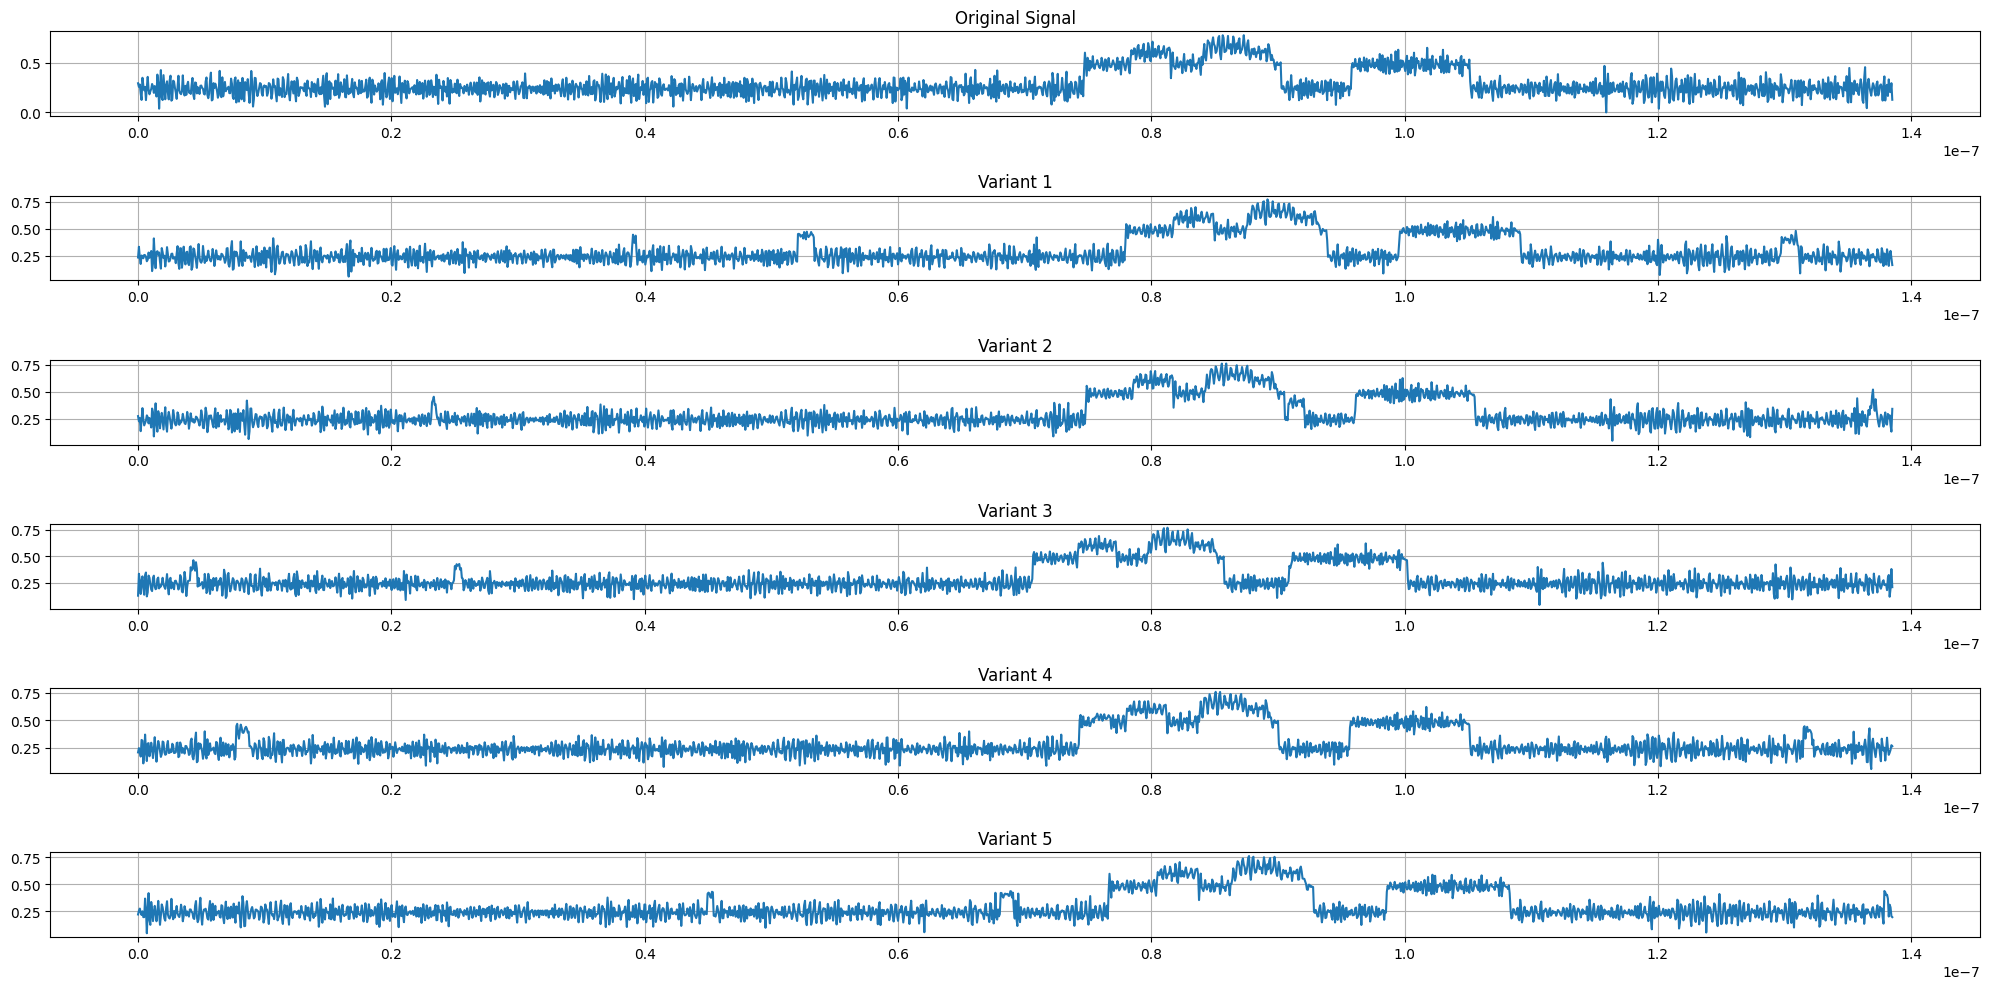

In [189]:
import matplotlib.pyplot as plt

# Step 1: Generate a base signal
t, wave, signal_range, interrupt_range, n_sinusoids, interrupt_params, temp, fs, amplitude_range, frequency_range = generate_single_signal(domain='Drones')

# Parameters needed for variant generation
#fs = max(svg.EMBEDDED_DEVICE_RANGES['Arduino Board']['frequency']) * 2  # following your previous num=2
#amplitude_range = signal_range['Arduino Board']['amplitude']
#frequency_range = signal_range['Arduino Board']['frequency']

# Step 2: Generate variants
variants, snr, color, max_warp, max_shift, _, _, _ = generate_signal_variants(
    svg, t, wave, domain='Drones', 
    n_variants=5, fs=fs, 
    n_sinusoids=n_sinusoids, 
    amplitude_range=amplitude_range, 
    frequency_range=frequency_range
)

# Step 3: Visualization
plt.figure(figsize=(20, 10))

# Plot original signal
plt.subplot(len(variants)+1, 1, 1)
plt.plot(t, wave)
plt.title('Original Signal')
plt.grid(True)

# Plot each variant
for idx, variant in enumerate(variants):
    plt.subplot(len(variants)+1, 1, idx+2)
    plt.plot(t, variant)
    plt.title(f'Variant {idx+1}')
    plt.grid(True)

plt.tight_layout()
plt.show()


In [191]:
n_rows, n_variants_per_row = 5000, 20
data = []
domains = ['Arduino Board', 'Drones', 'Cameras'] #list(svg.EMBEDDED_DEVICE_RANGES.keys())

for _ in range(n_rows):
    # Random domain selection
    domain = random.choice(domains)

    # Generate a single base signal
    t, wave, signal_range, interrupt_range, n_sinusoids, interrupt_params, temp, fs, amplitude_range, frequency_range = generate_single_signal(domain)

    # Generate multiple variants
    variants, snr, color, max_warp, max_shift, burst_type, n_small, n_big = generate_signal_variants(
        svg, t, wave, domain, n_variants=n_variants_per_row, fs=fs,
        n_sinusoids=n_sinusoids, amplitude_range=amplitude_range, frequency_range=frequency_range
    )

    interrupt_info = extract_interrupt_info(interrupt_params)

    #plt.figure(figsize=(20, 10))
    #for idx, variant in enumerate(variants):
    #    plt.subplot(len(variants)+1, 1, idx+2)
    #    plt.plot(t, variant)
    #    plt.title(f'Variant {idx+1}')
    #    plt.grid(True)
    #plt.show()

    # Prepare dictionary for this row
    row = {
        'domain': domain,
        'original_signal': wave,
        'n_sinusoids': n_sinusoids,
        'time': max(t),
        'sampling_frequency': fs,
        'snr': snr,
        'noise_color': color,
        **interrupt_info,
        'max_warp': max_warp,
        'max_shift': max_shift,
        'burst_type': burst_type,
        'n_small_bursts': n_small,
        'n_big_bursts': n_big
    }
    for idx, var in enumerate(variants):
        row[f'variant_{idx+1}'] = var

    data.append(row)

# Create DataFrame
df = pd.DataFrame(data)


In [192]:
df

,domain,original_signal,n_sinusoids,time,sampling_frequency,snr,noise_color,main_start_idx,main_end_idx,small1_start_idx,...,variant_11,variant_12,variant_13,variant_14,variant_15,variant_16,variant_17,variant_18,variant_19,variant_20
0,Cameras,"[0.24965525561891205, 0.19496744567691274, 0.1...",38,7.356380e+00,2.717369e+02,46,brown,84,255,1394.0,...,"[0.26621327136387346, 0.24342744956075038, 0.2...","[0.1949733853361272, 0.2294661338613318, 0.130...","[0.16703416001385293, 0.26041254552105725, 0.2...","[0.12264979561369675, 0.24325953552470234, 0.3...","[0.2169929816696944, 0.19006164799393285, 0.13...","[0.3238599716536306, 0.25010920406471593, 0.19...","[0.2582760614349385, 0.24584180900315902, 0.26...","[0.20156317794409204, 0.22823792434940093, 0.2...","[0.22893042134552316, 0.2552398795365265, 0.25...","[0.1569868781968745, 0.29300217306807086, 0.27..."
1,Cameras,"[0.14884959289919017, 0.28685663919503795, 0.3...",32,6.452974e+00,3.097796e+02,50,brown,1576,1770,NaN,...,"[0.28250829716216697, 0.33646038723838095, 0.2...","[0.1940232610800863, 0.17647828452920997, 0.24...","[0.27790537480167565, 0.18277444223631653, 0.2...","[0.29040372183537666, 0.23320499455009064, 0.1...","[0.20489264670241483, 0.1494048611114735, 0.23...","[0.24023073641837012, 0.24134734923009638, 0.2...","[0.2298722754955321, 0.1963424545355583, 0.218...","[0.23929056726145057, 0.21975389574670698, 0.1...","[0.13841661490044466, 0.22298892185594035, 0.3...","[0.18546278387577023, 0.20111150371099834, 0.1..."
2,Arduino Board,"[1.5171626112152206, 1.8486008911553597, 0.957...",49,7.819022e-02,2.556586e+04,31,blue,80,214,642.0,...,"[1.2293892877894612, 1.1649503629989642, 1.318...","[1.4274078641455286, 1.556484993475442, 1.0882...","[1.3760764356276365, 1.0366036035902821, 1.159...","[1.3036691318979938, 1.574136796082218, 0.9863...","[1.3070232919757518, 0.506542752829848, 0.5487...","[1.8339314979097627, 1.7504428287815033, 1.521...","[1.2296357903580897, 1.3111511141937922, 1.108...","[1.8263346472064483, 0.9388756746462413, 1.364...","[0.7209980846892422, 0.9039854623308131, 1.102...","[1.122400035919556, 1.2713529703670816, 1.6684..."
3,Arduino Board,"[1.2287758027893159, 1.787485963045467, 2.1463...",38,7.130251e-02,2.803548e+04,48,brown,187,340,1064.0,...,"[1.242424641152874, 1.3288342714789056, 1.1016...","[1.3488922802624659, 1.1287607613291826, 1.300...","[1.3505689509434766, 1.0989043220751786, 1.293...","[1.2557227153356596, 1.3260512030591785, 0.740...","[1.0857532353836161, 1.0991350666119912, 0.922...","[1.5959248510656459, 1.7414337441417844, 1.488...","[0.6306486581701088, 1.090140114913326, 1.6165...","[1.3461475510227292, 1.1139121603168283, 1.373...","[2.316349646193215, 2.4146468927732267, 2.5929...","[1.1059274513906312, 1.2811079089233808, 1.309..."
4,Drones,"[0.3111473553237591, 0.15721225494995894, 0.16...",10000,1.372437e-07,1.456534e+10,45,blue,1695,1915,763.0,...,"[0.21095537275102855, 0.2695649982872004, 0.26...","[0.2592436682481375, 0.2457310656972689, 0.151...","[0.2766161759456417, 0.21837863669862215, 0.18...","[0.2012187740056699, 0.24263816187922405, 0.28...","[0.39873626520794225, 0.24688819998429934, 0.1...","[0.19644162204852308, 0.20507981586601395, 0.2...","[0.2137604356055112, 0.22911092419051118, 0.28...","[0.16964249216550256, 0.24878847339083865, 0.2...","[0.24062450074984065, 0.2704386958675852, 0.19...","[0.09694025530369364, 0.18806162529348186, 0.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Arduino Board,"[1.265568371440268, 1.7874685694296018, 0.9494...",43,6.963592e-02,2.870645e+04,23,brown,927,1153,478.0,...,"[1.3555561947965975, 1.2817846919550324, 1.429...","[1.4790146077196815, 1.4265160451728593, 0.931...","[1.3264622452751538, 1.0651111942461229, 0.864...","[1.3767126162980943, 1.5638442172383697, 1.036...","[1.1889877561516489, 1.1113640138539693, 1.129...","[1.3811828200877838, 1.7377377159055194, 0.987...","[0.22428738276910132, 0.23262087

In [199]:
df.to_pickle('s3.pkl')

In [193]:
df.to_csv('dataset2.csv', index=False)